# Gym demo

Demonstrate the use of the the Gym interface and screen capture support

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd
import glob as glob
import time
import pickle
from omegaconf import OmegaConf
import cv2

# add custom paths
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

# Configure the logging system
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)



## Load config file

In [2]:
config = OmegaConf.load("config.yml")

config.AssettoCorsa.screen_capture_enable = True

# Create env object

In [3]:
env = assettoCorsa.make_ac_env(cfg=config, work_dir="output")


INFO:AssettoCorsaEnv.ac_env:Setting track ks_barcelona-layout_gp
INFO:AssettoCorsaEnv.track:Track loaded from: f:\code\assetto_corsa_gym-main\assetto_corsa_gym\AssettoCorsaEnv\../AssettoCorsaConfigs\tracks\ks_barcelona-layout_gp.csv Found 3000 segments downsampled by 10= 300 segments
INFO:AssettoCorsaEnv.reference_lap:Reference Lap. Loading: f:\code\assetto_corsa_gym-main\assetto_corsa_gym\AssettoCorsaEnv\../AssettoCorsaConfigs\tracks\ks_barcelona-layout_gp-racing_line_fixed.csv
INFO:AssettoCorsaEnv.reference_lap:Using curvature from racing line file
INFO:AssettoCorsaEnv.reference_lap:Reference Lap. Loading: f:\code\assetto_corsa_gym-main\assetto_corsa_gym\AssettoCorsaEnv\../AssettoCorsaConfigs\tracks\ks_barcelona-layout_gp.csv
INFO:AssettoCorsaEnv.reference_lap:Calculating curvature
INFO:AssettoCorsaEnv.reference_lap:Reference Lap. Loading: f:\code\assetto_corsa_gym-main\assetto_corsa_gym\AssettoCorsaEnv\../AssettoCorsaConfigs\tracks\ks_barcelona-layout_gp.csv
INFO:AssettoCorsaEnv.ref

# Show static info

In [7]:
static_info = env.env.env.client.simulation_management.get_static_info()
ac_mod_config = env.env.env.client.simulation_management.get_config()

logger.info("Static info:")
for i in static_info:
    logger.info(f"{i}: {static_info[i]}")
logger.info("AC Mod config:")
for i in ac_mod_config:
    logger.info(f"{i}: {ac_mod_config[i]}")


INFO:__main__:Static info:
INFO:__main__:LastSplits: [0, 0, 0]
INFO:__main__:isCarInPit: 0
INFO:__main__:CAR_TRACK: 1.6650463943271079
INFO:__main__:TyreContactPoint_RL: [362.59130859375, -18.870376586914062, -182.27349853515625]
INFO:__main__:TrackConfiguration: layout_gp
INFO:__main__:penaltiesEnabled: 1
INFO:__main__:autoShifterOn: 1
INFO:__main__:CAR_WHEELBASE: 2.5098979252355886
INFO:__main__:TrackName: ks_barcelona
INFO:__main__:WindDirection: 359
INFO:__main__:TrackLength: 4591.88720703125
INFO:__main__:WorldPosition: [361.1678771972656, -18.50563621520996, -181.59938049316406]
INFO:__main__:TyreContactPoint_FR: [359.8609619140625, -18.915084838867188, -181.0315704345703]
INFO:__main__:WindSpeed: 0
INFO:__main__:CAR_WHEEL_R: [0.3400000035762787, 0.3400000035762787, 0.35249999165534973, 0.35249999165534973]
INFO:__main__:TyreContactPoint_RR: [361.1855163574219, -18.909812927246094, -183.16488647460938]
INFO:__main__:CarName: bmw_z4_gt3
INFO:__main__:TyreContactPoint_FL: [361.2284

# Apply actions and recover the car

INFO:AssettoCorsaEnv.ac_env:Saved raw data to:
INFO:AssettoCorsaEnv.ac_env:output\laps\/20251217_171409.580_raw_data.pkl
INFO:AssettoCorsaEnv.ac_env:total_steps: 95 ep_steps: 81 ep_reward:    6.0 LapDist:  35.60 packages lost 0 BestLap: 0.0
INFO:AssettoCorsaEnv.ac_env:speed_mean:   6.74 speed_max:  14.76 max_abs_gap:   4.72 ep_laps: 1
INFO:AssettoCorsaEnv.ac_env:dt avr: 0.040 std: 0.001 min: 0.039 max: 0.042
INFO:AssettoCorsaEnv.ac_env:Reset AC. Episode 5 total_steps: 95
INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_client:AC Client. Listening at host: localhost port: 2345
INFO:AssettoCorsaEnv.ac_client:Client connected on 2345
c:\Users\Breeze\.conda\envs\p309\lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Breeze\.conda\envs\p309\lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's prec

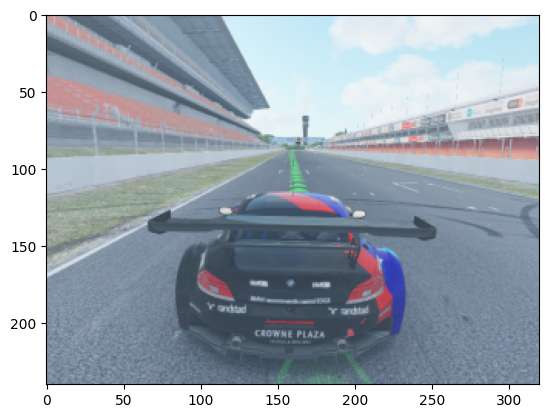

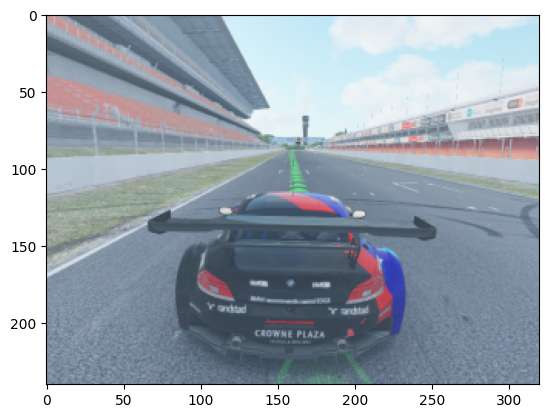

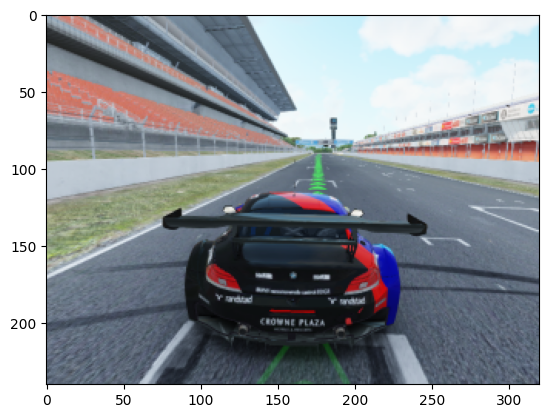

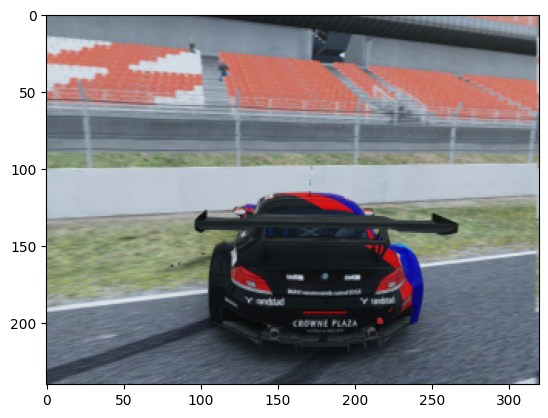

INFO:AssettoCorsaEnv.ac_env:Terminate episode. is_out_of_track
INFO:AssettoCorsaEnv.ac_env:out_of_track. N wheels out: 4. LapDist: 61.19717008924454 x: -140.25 y: 339.94
c:\Users\Breeze\.conda\envs\p309\lib\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Breeze\.conda\envs\p309\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
INFO:AssettoCorsaEnv.ac_env:Recover car
INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_env:Saved raw data to:
INFO:AssettoCorsaEnv.ac_env:output\laps\/20251217_171415.432_raw_data.pkl
INFO:AssettoCorsaEnv.ac_env:total_steps: 176 ep_steps: 78 ep_reward:    5.8 LapDist:  61.20 packages lost 0 BestLap: 0.0
INFO:AssettoCorsaEnv.ac_env:speed_mean:   6.72 speed_max:  14.36 max_abs_gap:   4.64 ep_laps: 1
INFO:AssettoCorsaEnv.ac_env:

(array([ 4.38888470e-05,  8.40248808e-04,  1.11184316e-03,  1.38832202e-01,
         0.00000000e+00,  0.00000000e+00,  1.25000000e-01, -2.89260346e-04,
         5.87594441e-06,  1.36372296e-04, -1.42115295e-02, -7.95441270e-03,
        -8.54211628e-03, -1.10646641e-02,  4.76362542e-02,  5.00251348e-02,
         5.87197050e-02,  8.06247144e-02,  1.52481146e-01,  1.00000000e+00,
         5.38965944e-02,  2.81894983e-02,  2.04407446e-02,  1.73669233e-02,
         1.65013427e-02,  0.00000000e+00,  5.21142011e-05,  6.45729677e-05,
         7.82079717e-05,  9.31133607e-05,  1.09374946e-04,  1.27069669e-04,
         1.46255820e-04,  1.66970277e-04,  1.89216120e-04,  2.12969416e-04,
         2.38150167e-04,  2.67037364e-04,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.0

In [12]:
states = []

env.reset()

for i in range(100):
    if i % 2 == 0:
        steer = .1
    else:
        steer = -.1
    env.env.env.set_actions(np.array([steer, 0.5, -1.]))
    next_state, reward, done,_, info = env.env.env.step(action=None)  # action is already applied
    if (i % 25) == 0:
        plt.imshow(cv2.cvtColor(env.env.env.get_current_image(), cv2.COLOR_BGR2RGB))
        plt.show()
    time.sleep(0.01)
    if done:
        break

env.env.env.recover_car()
env.env.env.close()

# Plot states

In [ ]:
df = env.get_history()
df.columns

In [ ]:
plt.title("Speed")
plt.plot(df.speed)
plt.show()

plt.title("steerAngle")
plt.plot(df.steerAngle)
plt.show()